<a href="https://colab.research.google.com/github/Akideaf/Engine-Detection-Thesis-/blob/main/resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install librosa soundfile tqdm

🔍 Checking GPU...
✅ GPU Available: /physical_device:GPU:0

📂 Verifying data folders...
✅ Detected 5 classes: ['Clicking', 'Knocking', 'Normal', 'Rod Knock', 'Timing Belt']
📊 Class mapping: {'Clicking': 0, 'Knocking': 1, 'Normal': 2, 'Rod Knock': 3, 'Timing Belt': 4}

📂 Collecting audio files from training set...
   Clicking: 2000 files
   Knocking: 2000 files
   Normal: 2000 files
   Rod Knock: 2000 files
   Timing Belt: 2000 files
✅ Total training samples: 10000

📂 Collecting audio files from validation set...
   Clicking: 15 files
   Knocking: 15 files
   Normal: 15 files
   Rod Knock: 14 files
   Timing Belt: 15 files
✅ Total validation samples: 74

🔄 Creating data generators...
✅ Training batches per epoch: 625
✅ Validation batches per epoch: 5

🧪 Testing spectrogram generation...
✅ Spectrogram shape: (224, 224, 3), dtype: uint8
   Min: 4, Max: 245

🏗️ Building ResNet50 Transfer Learning Model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✅ Model built!
   Total parameters:

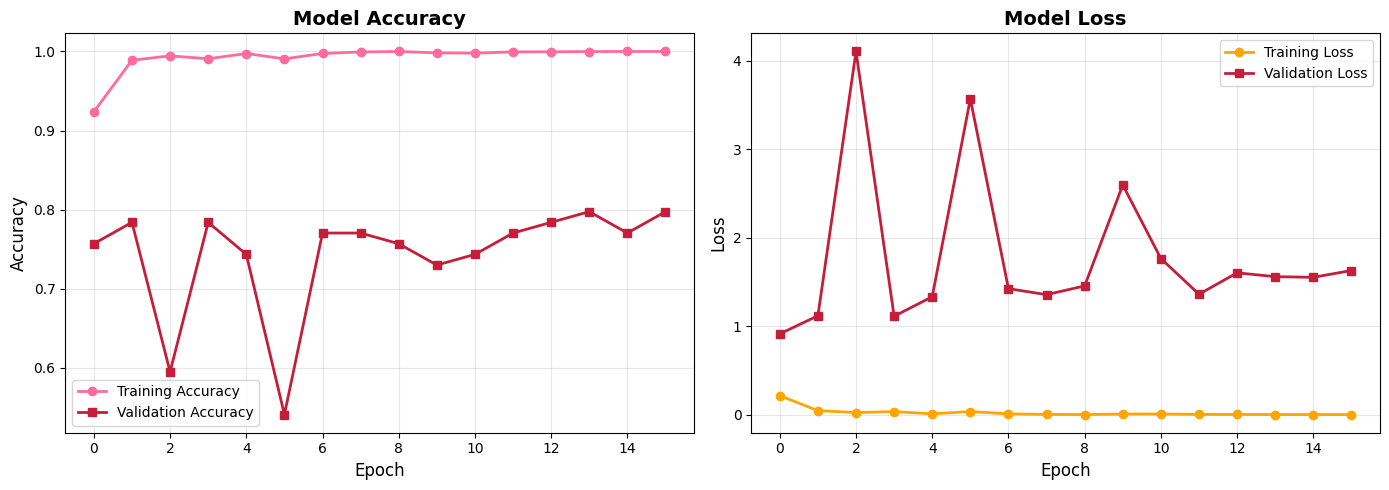

✅ Training curves saved!

🔍 Generating classification report...
Predicting on validation set...


100%|██████████| 5/5 [00:17<00:00,  3.55s/it]



📊 Generating validation evaluation graphs...


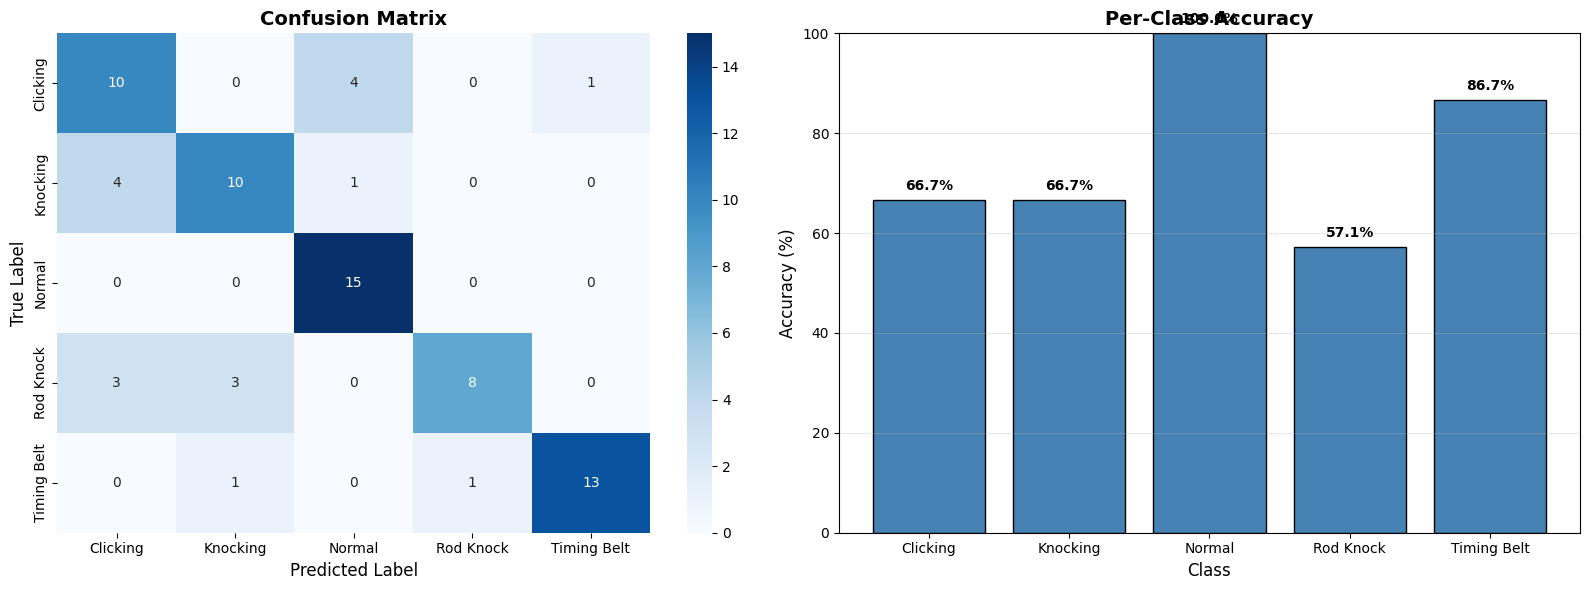

✅ Validation evaluation graphs saved!

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Clicking       0.59      0.67      0.62        15
    Knocking       0.71      0.67      0.69        15
      Normal       0.75      1.00      0.86        15
   Rod Knock       0.89      0.57      0.70        14
 Timing Belt       0.93      0.87      0.90        15

    accuracy                           0.76        74
   macro avg       0.77      0.75      0.75        74
weighted avg       0.77      0.76      0.75        74


📊 Confusion Matrix (labeled):
True/Pred      Clicking       Knocking       Normal         Rod Knock      Timing Belt    
Clicking       10             0              4              0              1              
Knocking       4              10             1              0              0              
Normal         0              0              15             0              0              
Rod Knock      3              3              0       

In [ ]:
import numpy as np
import os
import json
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# --- CONFIG ---
TRAIN_FOLDER = "/content/drive/MyDrive/AS-Augmented_Engine_Data_2k"
VALIDATION_FOLDER = "/content/drive/MyDrive/aug-validate"
BATCH_SIZE = 16
EPOCHS = 50
IMG_SIZE = (224, 224)
LEARNING_RATE = 1e-4

# Audio processing parameters
SAMPLE_RATE = 22050
DURATION = 5  # seconds
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048

print("🔍 Checking GPU...")
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    print("⚠️ WARNING: No GPU detected!")
else:
    print(f"✅ GPU Available: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Verify folders
print("\n📂 Verifying data folders...")
if not os.path.exists(TRAIN_FOLDER):
    raise FileNotFoundError(f"Training folder not found: {TRAIN_FOLDER}")
if not os.path.exists(VALIDATION_FOLDER):
    raise FileNotFoundError(f"Validation folder not found: {VALIDATION_FOLDER}")

# Get classes
classes = sorted([d for d in os.listdir(TRAIN_FOLDER)
                  if os.path.isdir(os.path.join(TRAIN_FOLDER, d))])
num_classes = len(classes)
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

print(f"✅ Detected {num_classes} classes: {classes}")
print(f"📊 Class mapping: {class_to_idx}")

# --- AUDIO TO SPECTROGRAM FUNCTION ---
def audio_to_mel_spectrogram(audio_path, sr=SAMPLE_RATE, duration=DURATION,
                             n_mels=N_MELS, hop_length=HOP_LENGTH, n_fft=N_FFT):
    """
    Convert audio file to RGB mel-spectrogram image
    Returns: numpy array of shape (224, 224, 3)
    """
    try:
        # Load audio file
        y, sr = librosa.load(audio_path, sr=sr, duration=duration)

        # Pad if shorter than duration
        target_length = sr * duration
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        else:
            y = y[:target_length]

        # Compute mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=n_mels,
            hop_length=hop_length,
            n_fft=n_fft
        )

        # Convert to dB scale
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Normalize to [0, 255]
        mel_spec_norm = ((mel_spec_db - mel_spec_db.min()) /
                         (mel_spec_db.max() - mel_spec_db.min()) * 255).astype(np.uint8)

        # Convert to RGB by stacking
        mel_spec_rgb = np.stack([mel_spec_norm] * 3, axis=-1)

        # Resize to 224x224 for ResNet50
        mel_spec_resized = cv2.resize(mel_spec_rgb, IMG_SIZE, interpolation=cv2.INTER_LINEAR)

        return mel_spec_resized

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        # Return blank spectrogram on error
        return np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.uint8)

# --- CUSTOM DATA GENERATOR ---
class AudioSpectrogramGenerator(Sequence):
    """
    Custom generator that converts audio files to spectrograms on-the-fly
    """
    def __init__(self, audio_paths, labels, batch_size=16, num_classes=5,
                 shuffle=True, augment=False):
        self.audio_paths = audio_paths
        self.labels = labels
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.audio_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.audio_paths) / self.batch_size))

    def __getitem__(self, index):
        # Get batch indices
        batch_indices = self.indices[index * self.batch_size :
                                     (index + 1) * self.batch_size]

        # Generate batch
        X_batch = []
        y_batch = []

        for idx in batch_indices:
            # Convert audio to spectrogram
            spec = audio_to_mel_spectrogram(self.audio_paths[idx])

            # Simple augmentation for training
            if self.augment and np.random.rand() > 0.5:
                # Random brightness adjustment
                spec = np.clip(spec.astype(np.float32) * np.random.uniform(0.8, 1.2), 0, 255).astype(np.uint8)

            X_batch.append(spec)
            y_batch.append(self.labels[idx])

        X_batch = np.array(X_batch, dtype=np.float32)

        # Apply ResNet50 preprocessing
        X_batch = preprocess_input(X_batch)

        # One-hot encode labels
        y_batch = tf.keras.utils.to_categorical(y_batch, num_classes=self.num_classes)

        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# --- COLLECT AUDIO FILES ---
print("\n📂 Collecting audio files from training set...")
train_audio_paths = []
train_labels = []

for class_name in classes:
    class_folder = os.path.join(TRAIN_FOLDER, class_name)
    audio_files = [f for f in os.listdir(class_folder)
                   if f.endswith(('.wav', '.mp3', '.flac', '.ogg', '.m4a'))]

    for audio_file in audio_files:
        train_audio_paths.append(os.path.join(class_folder, audio_file))
        train_labels.append(class_to_idx[class_name])

    print(f"   {class_name}: {len(audio_files)} files")

train_audio_paths = np.array(train_audio_paths)
train_labels = np.array(train_labels)
print(f"✅ Total training samples: {len(train_audio_paths)}")

print("\n📂 Collecting audio files from validation set...")
val_audio_paths = []
val_labels = []

for class_name in classes:
    class_folder = os.path.join(VALIDATION_FOLDER, class_name)
    if not os.path.exists(class_folder):
        print(f"⚠️ Warning: {class_name} folder not found in validation set")
        continue

    audio_files = [f for f in os.listdir(class_folder)
                   if f.endswith(('.wav', '.mp3', '.flac', '.ogg', '.m4a'))]

    for audio_file in audio_files:
        val_audio_paths.append(os.path.join(class_folder, audio_file))
        val_labels.append(class_to_idx[class_name])

    print(f"   {class_name}: {len(audio_files)} files")

val_audio_paths = np.array(val_audio_paths)
val_labels = np.array(val_labels)
print(f"✅ Total validation samples: {len(val_audio_paths)}")

# --- CREATE GENERATORS ---
print("\n🔄 Creating data generators...")
train_generator = AudioSpectrogramGenerator(
    train_audio_paths,
    train_labels,
    batch_size=BATCH_SIZE,
    num_classes=num_classes,
    shuffle=True,
    augment=True  # Enable augmentation for training
)

val_generator = AudioSpectrogramGenerator(
    val_audio_paths,
    val_labels,
    batch_size=BATCH_SIZE,
    num_classes=num_classes,
    shuffle=False,
    augment=False  # No augmentation for validation
)

print(f"✅ Training batches per epoch: {len(train_generator)}")
print(f"✅ Validation batches per epoch: {len(val_generator)}")

# --- TEST SPECTROGRAM GENERATION ---
print("\n🧪 Testing spectrogram generation...")
test_spec = audio_to_mel_spectrogram(train_audio_paths[0])
print(f"✅ Spectrogram shape: {test_spec.shape}, dtype: {test_spec.dtype}")
print(f"   Min: {test_spec.min()}, Max: {test_spec.max()}")

# --- BUILD RESNET50 MODEL ---
print("\n🏗️ Building ResNet50 Transfer Learning Model...")

input_layer = Input(shape=(224, 224, 3))

# Load ResNet50 with ImageNet weights
base_model = ResNet50(
    input_tensor=input_layer,
    include_top=False,
    weights='imagenet'
)

# Fine-tune entire model
base_model.trainable = True

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D(name='global_avg_pool')(x)
x = Dense(512, activation='relu', name='fc1')(x)
x = Dropout(0.5, name='dropout1')(x)
x = Dense(256, activation='relu', name='fc2')(x)
x = Dropout(0.3, name='dropout2')(x)
predictions = Dense(num_classes, activation='softmax', name='output')(x)

model = Model(inputs=input_layer, outputs=predictions)

# Compile
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✅ Model built!")
print(f"   Total parameters: {model.count_params():,}")
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"   Trainable parameters: {trainable_params:,}")

# --- CALLBACKS ---
print("\n⚙️ Setting up callbacks...")

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/resnet50_audio_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

csv_logger = tf.keras.callbacks.CSVLogger(
    '/content/drive/MyDrive/training_log.csv'
)

# --- TRAIN ---
print("\n🚀 Starting Training...")
print("="*70)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr, csv_logger],
    verbose=1
)

# --- SAVE ARTIFACTS ---
print("\n💾 Saving training artifacts...")

np.save("/content/drive/MyDrive/training_history.npy", history.history)

with open("/content/drive/MyDrive/class_indices.json", 'w') as f:
    json.dump(class_to_idx, f, indent=2)

model.save("/content/drive/MyDrive/resnet50_audio_final.keras")

print("✅ All artifacts saved!")

# --- FINAL EVALUATION ---
print("\n📊 Final Evaluation:")
print("="*70)

val_loss, val_acc = model.evaluate(val_generator, verbose=1)
print(f"\n🎯 Results:")
print(f"   Validation Loss: {val_loss:.4f}")
print(f"   Validation Accuracy: {val_acc*100:.2f}%")

# --- GENERATE TRAINING CURVES ---
print("\n📊 Generating training curves...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], 'o-', label='Training Accuracy', linewidth=2, color='#FF6B9D')
axes[0].plot(history.history['val_accuracy'], 's-', label='Validation Accuracy', linewidth=2, color='#C41E3A')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], 'o-', label='Training Loss', linewidth=2, color='#FFA500')
axes[1].plot(history.history['val_loss'], 's-', label='Validation Loss', linewidth=2, color='#C41E3A')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves_resnet50.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training curves saved!")

# --- DETAILED PREDICTIONS ---
print("\n🔍 Generating classification report...")

y_true = val_labels
y_pred = []

print("Predicting on validation set...")
for i in tqdm(range(len(val_generator))):
    X_batch, _ = val_generator[i]
    preds = model.predict(X_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

y_pred = np.array(y_pred[:len(y_true)])  # Trim to actual size

# Calculate per-class accuracy
class_accuracies = []
for i in range(num_classes):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        class_accuracies.append(class_acc * 100)
    else:
        class_accuracies.append(0)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# --- GENERATE VALIDATION EVALUATION GRAPHS ---
print("\n📊 Generating validation evaluation graphs...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Per-Class Accuracy
axes[1].bar(classes, class_accuracies, color='steelblue', edgecolor='black')
axes[1].set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_accuracies):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/validation_evaluation_resnet50.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Validation evaluation graphs saved!")

# --- CLASSIFICATION REPORT ---
print("\n" + "="*70)
print("📋 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=classes))

# Save confusion matrix
np.save("/content/drive/MyDrive/confusion_matrix.npy", cm)

# Pretty print
print("\n📊 Confusion Matrix (labeled):")
print(f"{'True/Pred':<15}", end="")
for cls in classes:
    print(f"{cls:<15}", end="")
print()
for i, cls in enumerate(classes):
    print(f"{cls:<15}", end="")
    for j in range(num_classes):
        print(f"{cm[i,j]:<15}", end="")
    print()

# --- FINAL SUMMARY ---
print("\n" + "="*70)
print("📊 FINAL SUMMARY")
print("="*70)
print(f"Final Training Accuracy:   {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"Final Training Loss:       {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss:     {history.history['val_loss'][-1]:.4f}")
print(f"\nBest Validation Accuracy:  {max(history.history['val_accuracy'])*100:.2f}%")
print(f"Best Epoch:                {np.argmax(history.history['val_accuracy']) + 1}")
print("="*70)

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)
print("📁 FILES SAVED:")
print("  - resnet50_audio_best.keras (best model)")
print("  - resnet50_audio_final.keras (final model)")
print("  - training_curves_resnet50.png (accuracy/loss graphs)")
print("  - validation_evaluation_resnet50.png (confusion matrix + per-class accuracy)")
print("  - training_history.npy (training history)")
print("  - class_indices.json (class mapping)")
print("  - training_log.csv (detailed training log)")
print("  - confusion_matrix.npy (confusion matrix data)")
print("="*70)

🎵 YAMNet Audio Classification System
📌 Approach: YAMNet Embeddings → Custom Classifier
📌 Different from ResNet50: Uses pre-extracted audio features

🔍 Checking GPU...
✅ GPU Available: /physical_device:GPU:0

📂 Verifying data folders...
✅ Detected 5 classes: ['Clicking', 'Knocking', 'Normal', 'Rod Knock', 'Timing Belt']
📊 Class mapping: {'Clicking': 0, 'Knocking': 1, 'Normal': 2, 'Rod Knock': 3, 'Timing Belt': 4}

🎵 Loading YAMNet model from TensorFlow Hub...
✅ YAMNet loaded successfully!
   YAMNet produces 1024-dimensional embeddings from audio

📂 Collecting and extracting embeddings from TRAINING set...
   (This may take a while...)

   Processing Clicking...


   Clicking: 100%|██████████| 2000/2000 [02:07<00:00, 15.72it/s]



   Processing Knocking...


   Knocking: 100%|██████████| 2000/2000 [01:44<00:00, 19.15it/s]



   Processing Normal...


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ yamnet_embedding (InputLayer)   │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,253 (2.64 MB)

 Trainable params: 691,461 (2.64 MB)

 Non-trainable params: 1,792 (7.00 KB)


⚙️ Setting up callbacks...

🚀 Starting Training...
📌 Training Strategy: Direct embedding classification
📌 Advantage: Much faster than spectrogram approach
📌 YAMNet features are pre-learned from AudioSet

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7333 - loss: 0.7802
Epoch 1: val_accuracy improved from -inf to 0.71622, saving model to /content/drive/MyDrive/yamnet_audio_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.7336 - loss: 0.7792 - val_accuracy: 0.7162 - val_loss: 1.4958 - learning_rate: 0.0010
Epoch 2/100
297/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9355 - loss: 0.1929
Epoch 2: val_accuracy did not improve from 0.71622
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9358 - loss: 0.1921 - val_accuracy: 0.7162 - val_loss: 3.3156 - learning_rate: 0.0010
Epoch 3/100
298/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9624 - loss: 0.1192
Epoch 3: val_accuracy did not improve from 0.71622
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s

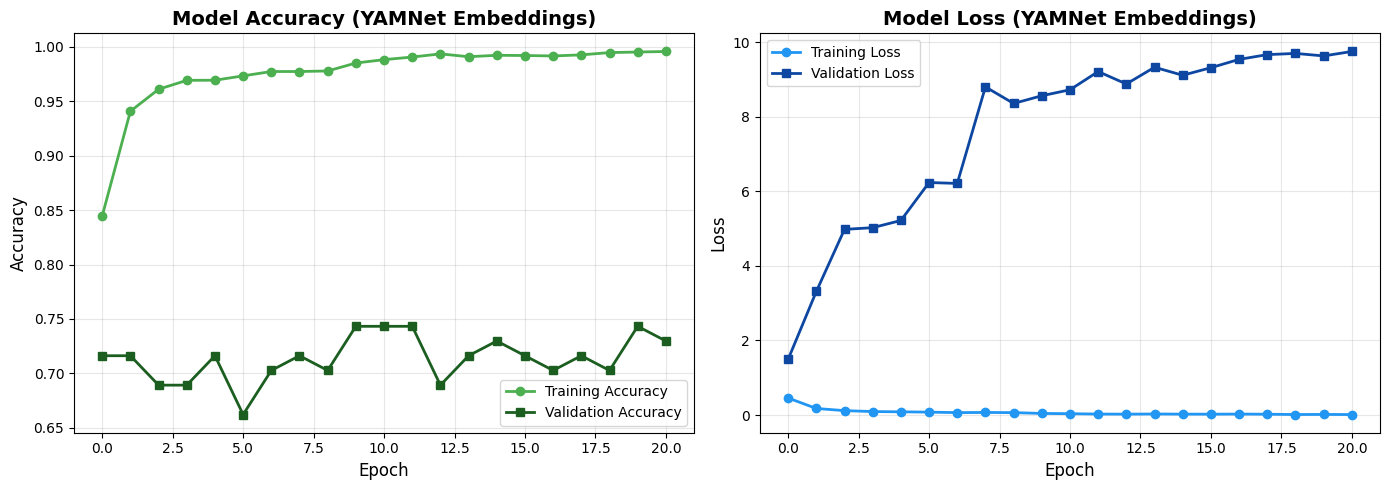

✅ Training curves saved!

🔍 Generating detailed predictions...

📊 Generating validation evaluation graphs...


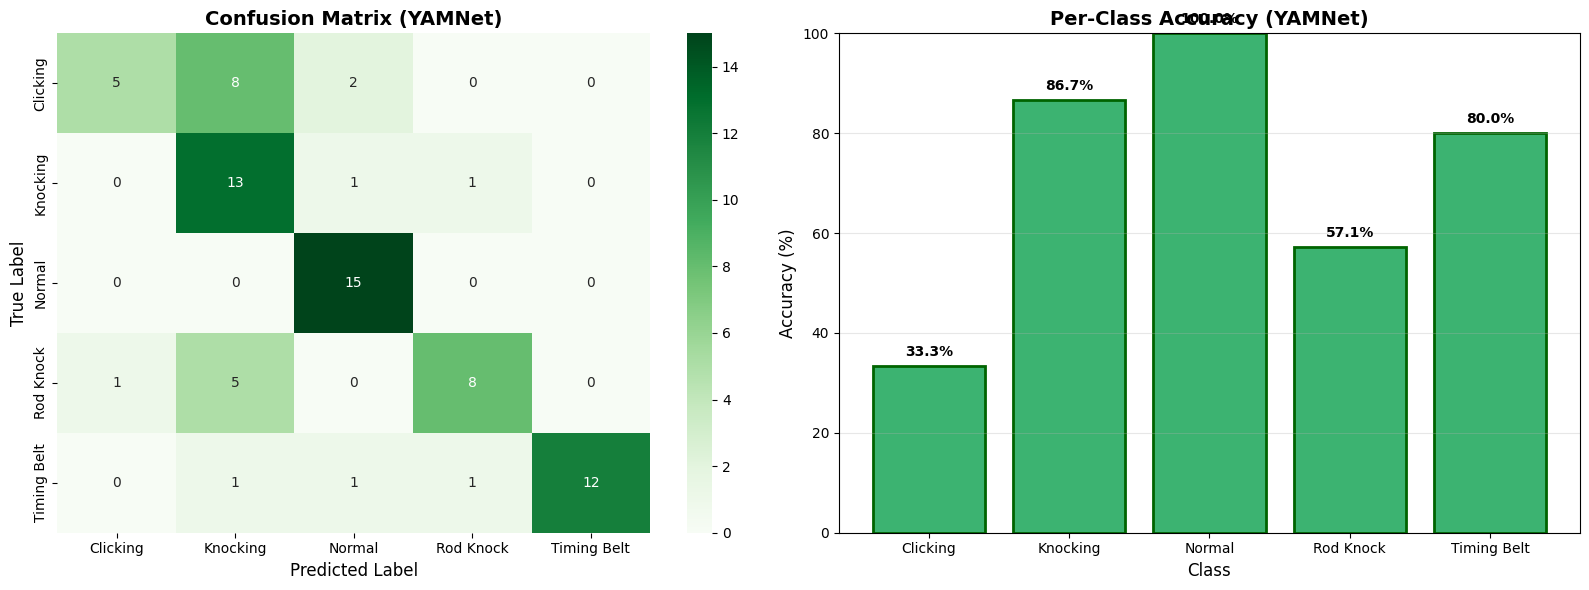

✅ Validation evaluation graphs saved!

📋 CLASSIFICATION REPORT (YAMNet)
              precision    recall  f1-score   support

    Clicking       0.83      0.33      0.48        15
    Knocking       0.48      0.87      0.62        15
      Normal       0.79      1.00      0.88        15
   Rod Knock       0.80      0.57      0.67        14
 Timing Belt       1.00      0.80      0.89        15

    accuracy                           0.72        74
   macro avg       0.78      0.71      0.71        74
weighted avg       0.78      0.72      0.71        74


📊 Confusion Matrix (labeled):
True/Pred      Clicking       Knocking       Normal         Rod Knock      Timing Belt    
Clicking       5              8              2              0              0              
Knocking       0              13             1              1              0              
Normal         0              0              15             0              0              
Rod Knock      1              5             

In [ ]:
import numpy as np
import os
import json
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from google.colab import drive
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import librosa
import warnings
warnings.filterwarnings('ignore')

# --- CONFIG ---
TRAIN_FOLDER = "/content/drive/MyDrive/AS-Augmented_Engine_Data_2k"
VAL_FOLDER = "/content/drive/MyDrive/aug-validate"
BATCH_SIZE = 32  # Larger batch size since we're using embeddings
EPOCHS = 100
LEARNING_RATE = 0.001  # Higher LR for embedding-based approach

# YAMNet expects 16kHz mono audio
SAMPLE_RATE = 16000
DURATION = 5

print("🎵 YAMNet Audio Classification System")
print("="*70)
print("📌 Approach: YAMNet Embeddings → Custom Classifier")
print("📌 Different from ResNet50: Uses pre-extracted audio features")
print("="*70)

print("\n🔍 Checking GPU...")
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    print("⚠️ WARNING: No GPU detected!")
else:
    print(f"✅ GPU Available: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Verify folders
print("\n📂 Verifying data folders...")
if not os.path.exists(TRAIN_FOLDER):
    raise FileNotFoundError(f"Training folder not found: {TRAIN_FOLDER}")
if not os.path.exists(VAL_FOLDER):
    raise FileNotFoundError(f"Validation folder not found: {VAL_FOLDER}")

# Get classes
classes = sorted([d for d in os.listdir(TRAIN_FOLDER)
                  if os.path.isdir(os.path.join(TRAIN_FOLDER, d))])
num_classes = len(classes)
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

print(f"✅ Detected {num_classes} classes: {classes}")
print(f"📊 Class mapping: {class_to_idx}")

# --- LOAD YAMNET MODEL ---
print("\n🎵 Loading YAMNet model from TensorFlow Hub...")
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print("✅ YAMNet loaded successfully!")
print("   YAMNet produces 1024-dimensional embeddings from audio")

# --- AUDIO LOADING FUNCTION ---
def load_audio_for_yamnet(audio_path, sr=SAMPLE_RATE, duration=DURATION):
    """
    Load audio file for YAMNet processing
    YAMNet expects 16kHz mono audio
    """
    try:
        # Load audio
        y, _ = librosa.load(audio_path, sr=sr, duration=duration, mono=True)

        # Pad or trim to exact duration
        target_length = sr * duration
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        else:
            y = y[:target_length]

        return y.astype(np.float32)

    except Exception as e:
        print(f"Error loading {audio_path}: {e}")
        return np.zeros(sr * duration, dtype=np.float32)

# --- EXTRACT YAMNET EMBEDDINGS ---
def extract_yamnet_embeddings(audio_waveform):
    """
    Extract YAMNet embeddings from audio waveform
    Returns: averaged embedding (1024,)
    """
    # YAMNet expects waveform as input
    scores, embeddings, spectrogram = yamnet_model(audio_waveform)

    # Average embeddings across time (temporal pooling)
    # This gives us a single 1024-dim vector per audio file
    embedding = tf.reduce_mean(embeddings, axis=0)

    return embedding.numpy()

# --- COLLECT AND EXTRACT EMBEDDINGS ---
print("\n📂 Collecting and extracting embeddings from TRAINING set...")
print("   (This may take a while...)")

X_train = []
y_train = []

for class_name in classes:
    class_folder = os.path.join(TRAIN_FOLDER, class_name)
    audio_files = [f for f in os.listdir(class_folder)
                   if f.endswith(('.wav', '.mp3', '.flac', '.ogg', '.m4a'))]

    print(f"\n   Processing {class_name}...")
    for audio_file in tqdm(audio_files, desc=f"   {class_name}"):
        audio_path = os.path.join(class_folder, audio_file)

        # Load audio
        waveform = load_audio_for_yamnet(audio_path)

        # Extract embedding
        embedding = extract_yamnet_embeddings(waveform)

        X_train.append(embedding)
        y_train.append(class_to_idx[class_name])

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"\n✅ Training embeddings extracted: {X_train.shape}")
print(f"   Shape: ({len(X_train)} samples, 1024 features)")

print("\n📂 Collecting and extracting embeddings from VALIDATION set...")

X_val = []
y_val = []

for class_name in classes:
    class_folder = os.path.join(VAL_FOLDER, class_name)
    if not os.path.exists(class_folder):
        print(f"⚠️ Warning: {class_name} folder not found in validation set")
        continue

    audio_files = [f for f in os.listdir(class_folder)
                   if f.endswith(('.wav', '.mp3', '.flac', '.ogg', '.m4a'))]

    print(f"\n   Processing {class_name}...")
    for audio_file in tqdm(audio_files, desc=f"   {class_name}"):
        audio_path = os.path.join(class_folder, audio_file)

        # Load audio
        waveform = load_audio_for_yamnet(audio_path)

        # Extract embedding
        embedding = extract_yamnet_embeddings(waveform)

        X_val.append(embedding)
        y_val.append(class_to_idx[class_name])

X_val = np.array(X_val)
y_val = np.array(y_val)

print(f"\n✅ Validation embeddings extracted: {X_val.shape}")
print(f"   Shape: ({len(X_val)} samples, 1024 features)")

# --- DATASET SUMMARY ---
print("\n" + "="*70)
print("📊 DATASET SUMMARY")
print("="*70)
print(f"Training samples:   {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Total samples:      {len(X_train) + len(X_val):,}")
print(f"Embedding dimension: 1024 (YAMNet features)")
print(f"Number of classes:  {num_classes}")
print(f"Batch size:         {BATCH_SIZE}")
print("="*70 + "\n")

# Class distribution
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_val, counts_val = np.unique(y_val, return_counts=True)

print("📊 Class distribution:")
print(f"{'Class':<15} {'Training':<10} {'Validation':<12}")
print("-"*37)
for i, class_name in enumerate(classes):
    train_count = counts_train[i] if i < len(counts_train) else 0
    val_count = counts_val[i] if i < len(counts_val) else 0
    print(f"{class_name:<15} {train_count:<10} {val_count:<12}")
print()

# --- BUILD CLASSIFIER MODEL ---
print("\n🏗️ Building YAMNet Classifier...")
print("   Architecture: YAMNet Embeddings → Dense Layers → Softmax")

# Input is YAMNet embedding (1024 features)
input_layer = Input(shape=(1024,), name='yamnet_embedding')

# Deep classifier network
x = Dense(512, activation='relu', name='fc1')(input_layer)
x = BatchNormalization(name='bn1')(x)
x = Dropout(0.5, name='dropout1')(x)

x = Dense(256, activation='relu', name='fc2')(x)
x = BatchNormalization(name='bn2')(x)
x = Dropout(0.4, name='dropout2')(x)

x = Dense(128, activation='relu', name='fc3')(x)
x = BatchNormalization(name='bn3')(x)
x = Dropout(0.3, name='dropout3')(x)

# Output layer
predictions = Dense(num_classes, activation='softmax', name='output')(x)

model = Model(inputs=input_layer, outputs=predictions)

# Compile
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',  # Using integer labels
    metrics=['accuracy']
)

print(f"✅ Model built!")
print(f"   Total parameters: {model.count_params():,}")
model.summary()

# --- CALLBACKS ---
print("\n⚙️ Setting up callbacks...")

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/yamnet_audio_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-7,
    verbose=1
)

csv_logger = tf.keras.callbacks.CSVLogger(
    '/content/drive/MyDrive/yamnet_training_log.csv'
)

# --- TRAIN ---
print("\n🚀 Starting Training...")
print("="*70)
print("📌 Training Strategy: Direct embedding classification")
print("📌 Advantage: Much faster than spectrogram approach")
print("📌 YAMNet features are pre-learned from AudioSet")
print("="*70 + "\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr, csv_logger],
    verbose=1
)

# --- SAVE ARTIFACTS ---
print("\n💾 Saving training artifacts...")

np.save("/content/drive/MyDrive/yamnet_training_history.npy", history.history)
np.save("/content/drive/MyDrive/yamnet_X_train.npy", X_train)
np.save("/content/drive/MyDrive/yamnet_y_train.npy", y_train)
np.save("/content/drive/MyDrive/yamnet_X_val.npy", X_val)
np.save("/content/drive/MyDrive/yamnet_y_val.npy", y_val)

with open("/content/drive/MyDrive/yamnet_class_indices.json", 'w') as f:
    json.dump(class_to_idx, f, indent=2)

model.save("/content/drive/MyDrive/yamnet_audio_final.keras")

print("✅ All artifacts saved!")

# --- GENERATE TRAINING CURVES ---
print("\n📊 Generating training curves...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], 'o-', label='Training Accuracy', linewidth=2, color='#4CAF50')
axes[0].plot(history.history['val_accuracy'], 's-', label='Validation Accuracy', linewidth=2, color='#1B5E20')
axes[0].set_title('Model Accuracy (YAMNet Embeddings)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], 'o-', label='Training Loss', linewidth=2, color='#2196F3')
axes[1].plot(history.history['val_loss'], 's-', label='Validation Loss', linewidth=2, color='#0D47A1')
axes[1].set_title('Model Loss (YAMNet Embeddings)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/yamnet_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training curves saved!")

# --- DETAILED PREDICTIONS ---
print("\n🔍 Generating detailed predictions...")

# Get predictions
y_pred_probs = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate per-class accuracy
class_accuracies = []
for i in range(num_classes):
    mask = y_val == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        class_accuracies.append(class_acc * 100)
    else:
        class_accuracies.append(0)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

# --- GENERATE VALIDATION EVALUATION GRAPHS ---
print("\n📊 Generating validation evaluation graphs...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Confusion Matrix (YAMNet)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Per-Class Accuracy
axes[1].bar(classes, class_accuracies, color='mediumseagreen', edgecolor='darkgreen', linewidth=2)
axes[1].set_title('Per-Class Accuracy (YAMNet)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_accuracies):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/yamnet_validation_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Validation evaluation graphs saved!")

# --- CLASSIFICATION REPORT ---
print("\n" + "="*70)
print("📋 CLASSIFICATION REPORT (YAMNet)")
print("="*70)
print(classification_report(y_val, y_pred, target_names=classes))

# Save confusion matrix
np.save("/content/drive/MyDrive/yamnet_confusion_matrix.npy", cm)

# Pretty print
print("\n📊 Confusion Matrix (labeled):")
print(f"{'True/Pred':<15}", end="")
for cls in classes:
    print(f"{cls:<15}", end="")
print()
for i, cls in enumerate(classes):
    print(f"{cls:<15}", end="")
    for j in range(num_classes):
        print(f"{cm[i,j]:<15}", end="")
    print()

# --- FINAL SUMMARY ---
print("\n" + "="*70)
print("📊 FINAL SUMMARY (YAMNet Embedding Approach)")
print("="*70)
print(f"Final Training Accuracy:   {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"Final Training Loss:       {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss:     {history.history['val_loss'][-1]:.4f}")
print(f"\nBest Validation Accuracy:  {max(history.history['val_accuracy'])*100:.2f}%")
print(f"Best Epoch:                {np.argmax(history.history['val_accuracy']) + 1}")
print(f"\n🎯 Overall Validation Accuracy: {(y_pred == y_val).sum() / len(y_val) * 100:.2f}%")
print("="*70)

print("\n" + "="*70)
print("✅ YAMNET TRAINING COMPLETE!")
print("="*70)
print("📁 FILES SAVED:")
print("  - yamnet_audio_best.keras (best model)")
print("  - yamnet_audio_final.keras (final model)")
print("  - yamnet_training_curves.png (accuracy/loss graphs - GREEN theme)")
print("  - yamnet_validation_evaluation.png (confusion matrix + per-class accuracy)")
print("  - yamnet_training_history.npy (training history)")
print("  - yamnet_class_indices.json (class mapping)")
print("  - yamnet_training_log.csv (detailed training log)")
print("  - yamnet_confusion_matrix.npy (confusion matrix data)")
print("  - yamnet_X_train.npy (training embeddings - reusable)")
print("  - yamnet_y_train.npy (training labels)")
print("  - yamnet_X_val.npy (validation embeddings)")
print("  - yamnet_y_val.npy (validation labels)")
print("\n🎵 YAMNet Approach Advantages:")
print("  ✓ Uses pre-trained audio features from AudioSet (70M+ audio clips)")
print("  ✓ Much faster training (no spectrogram generation needed)")
print("  ✓ Embeddings can be reused for different experiments")
print("  ✓ Works well for general audio classification tasks")
print("="*70)

In [ ]:
import numpy as np
import os
import json
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from google.colab import drive
from tqdm import tqdm
import librosa
import cv2
import warnings
warnings.filterwarnings('ignore')

# --- CONFIG ---
TRAIN_FOLDER = "/content/drive/MyDrive/AS-Augmented_Engine_Data_2k"
VALIDATION_FOLDER = "/content/drive/MyDrive/aug-validate"
BATCH_SIZE = 32  # Increased from 16 for faster training
EPOCHS = 50
IMG_SIZE = (224, 224)

# Audio processing parameters
SAMPLE_RATE = 22050
DURATION = 5
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048

print("🔍 Checking GPU...")
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    print("⚠️ WARNING: No GPU detected!")
else:
    print(f"✅ GPU Available: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Verify folders
print("\n📂 Verifying data folders...")
if not os.path.exists(TRAIN_FOLDER):
    raise FileNotFoundError(f"Training folder not found: {TRAIN_FOLDER}")
if not os.path.exists(VALIDATION_FOLDER):
    raise FileNotFoundError(f"Validation folder not found: {VALIDATION_FOLDER}")

# Get classes
classes = sorted([d for d in os.listdir(TRAIN_FOLDER)
                  if os.path.isdir(os.path.join(TRAIN_FOLDER, d))])
num_classes = len(classes)
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

print(f"✅ Detected {num_classes} classes: {classes}")
print(f"📊 Class mapping: {class_to_idx}")

# --- OPTIMIZED AUDIO TO SPECTROGRAM FUNCTION ---
def audio_to_mel_spectrogram(audio_path, sr=SAMPLE_RATE, duration=DURATION,
                             n_mels=N_MELS, hop_length=HOP_LENGTH, n_fft=N_FFT):
    """
    Convert audio file to RGB mel-spectrogram image
    Returns: numpy array of shape (224, 224, 3) normalized to [0, 1]
    """
    try:
        # Load audio file (faster with mono and fixed duration)
        y, sr = librosa.load(audio_path, sr=sr, duration=duration, mono=True)

        # Pad if shorter than duration
        target_length = sr * duration
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        else:
            y = y[:target_length]

        # Compute mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=n_mels,
            hop_length=hop_length,
            n_fft=n_fft,
            power=2.0
        )

        # Convert to dB scale
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Normalize to [0, 1]
        mel_spec_norm = ((mel_spec_db - mel_spec_db.min()) /
                         (mel_spec_db.max() - mel_spec_db.min() + 1e-8))

        # Convert to RGB by stacking
        mel_spec_rgb = np.stack([mel_spec_norm] * 3, axis=-1)

        # Resize to 224x224
        mel_spec_resized = cv2.resize(mel_spec_rgb, IMG_SIZE, interpolation=cv2.INTER_LINEAR)

        return mel_spec_resized.astype(np.float32)

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.float32)

# --- STRONGER AUGMENTATION FUNCTION ---
def spectrogram_augmentation(spec):
    """Apply stronger augmentations during training"""
    spec = spec.copy()

    # Time shift (horizontal roll) - INCREASED
    if np.random.random() < 0.9:
        shift = np.random.randint(-30, 30)
        spec = np.roll(spec, shift, axis=1)

    # Gain adjustment (brightness) - INCREASED
    if np.random.random() < 0.8:
        gain = np.random.uniform(0.7, 1.3)
        spec = np.clip(spec * gain, 0, 1)

    # Frequency shift (vertical roll) - INCREASED
    if np.random.random() < 0.7:
        freq_shift = np.random.randint(-15, 15)
        spec = np.roll(spec, freq_shift, axis=0)

    # Small noise - INCREASED
    if np.random.random() < 0.5:
        noise = np.random.normal(0, 0.015, spec.shape)
        spec = np.clip(spec + noise, 0, 1)

    return spec.astype(np.float32)

# --- OPTIMIZED AUDIO GENERATOR WITH CACHING ---
class AudioSpectrogramGenerator(tf.keras.utils.Sequence):
    """
    Custom generator that converts audio files to spectrograms on-the-fly
    """
    def __init__(self, audio_paths, labels, batch_size=16, num_classes=5,
                 shuffle=True, augment=False):
        self.audio_paths = audio_paths
        self.labels = labels
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.audio_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.audio_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size : (index + 1) * self.batch_size]

        X_batch = []
        y_batch = []

        for idx in batch_indices:
            # Convert audio to spectrogram
            spec = audio_to_mel_spectrogram(self.audio_paths[idx])

            # Apply augmentation for training
            if self.augment:
                spec = spectrogram_augmentation(spec)

            X_batch.append(spec)
            y_batch.append(self.labels[idx])

        X_batch = np.array(X_batch, dtype=np.float32)
        y_batch = tf.keras.utils.to_categorical(y_batch, num_classes=self.num_classes)

        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# --- COLLECT TRAINING AUDIO FILES ---
print("\n📂 Collecting audio files from training set...")
train_audio_paths = []
train_labels = []

for class_name in classes:
    class_folder = os.path.join(TRAIN_FOLDER, class_name)
    audio_files = [f for f in os.listdir(class_folder)
                   if f.endswith(('.wav', '.mp3', '.flac', '.ogg', '.m4a'))]

    for audio_file in audio_files:
        train_audio_paths.append(os.path.join(class_folder, audio_file))
        train_labels.append(class_to_idx[class_name])

    print(f"   {class_name}: {len(audio_files)} files")

train_audio_paths = np.array(train_audio_paths)
train_labels = np.array(train_labels)
print(f"✅ Total training samples: {len(train_audio_paths)}")

# --- COLLECT VALIDATION AUDIO FILES ---
print("\n📂 Collecting audio files from validation set...")
val_audio_paths = []
val_labels = []

for class_name in classes:
    class_folder = os.path.join(VALIDATION_FOLDER, class_name)
    if not os.path.exists(class_folder):
        print(f"⚠️ Warning: {class_name} folder not found in validation set")
        continue

    audio_files = [f for f in os.listdir(class_folder)
                   if f.endswith(('.wav', '.mp3', '.flac', '.ogg', '.m4a'))]

    for audio_file in audio_files:
        val_audio_paths.append(os.path.join(class_folder, audio_file))
        val_labels.append(class_to_idx[class_name])

    print(f"   {class_name}: {len(audio_files)} files")

val_audio_paths = np.array(val_audio_paths)
val_labels = np.array(val_labels)
print(f"✅ Total validation samples: {len(val_audio_paths)}")

# --- CHECK CLASS DISTRIBUTION ---
print("\n📊 Training class distribution:")
unique, counts = np.unique(train_labels, return_counts=True)
for i, cls in enumerate(classes):
    print(f"   {cls}: {counts[i]} ({counts[i]/len(train_labels)*100:.1f}%)")

print("\n📊 Validation class distribution:")
unique, counts = np.unique(val_labels, return_counts=True)
for i, cls in enumerate(classes):
    print(f"   {cls}: {counts[i]} ({counts[i]/len(val_labels)*100:.1f}%)")

# --- CALCULATE CLASS WEIGHTS ---
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print(f"\n⚖️ Class weights: {class_weight_dict}")

# --- CREATE GENERATORS ---
print("\n🔄 Creating data generators...")
train_generator = AudioSpectrogramGenerator(
    train_audio_paths,
    train_labels,
    batch_size=BATCH_SIZE,
    num_classes=num_classes,
    shuffle=True,
    augment=True  # Enable augmentation for training
)

val_generator = AudioSpectrogramGenerator(
    val_audio_paths,
    val_labels,
    batch_size=BATCH_SIZE,
    num_classes=num_classes,
    shuffle=False,
    augment=False  # No augmentation for validation
)

print(f"✅ Training batches per epoch: {len(train_generator)}")
print(f"✅ Validation batches per epoch: {len(val_generator)}")

# --- TEST SPECTROGRAM GENERATION ---
print("\n🧪 Testing spectrogram generation...")
test_spec = audio_to_mel_spectrogram(train_audio_paths[0])
print(f"✅ Spectrogram shape: {test_spec.shape}, dtype: {test_spec.dtype}")
print(f"   Min: {test_spec.min():.4f}, Max: {test_spec.max():.4f}")

# --- BUILD MODEL WITH REDUCED REGULARIZATION ---
print("\n🏗️ Building MobileNetV2 with Lighter Regularization...")

input_layer = Input(shape=(224, 224, 3))
base_model = MobileNetV2(input_tensor=input_layer, include_top=False, weights='imagenet')
base_model.trainable = False  # Keep frozen

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)  # REDUCED from 0.6
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)  # REDUCED L2
x = Dropout(0.3)(x)  # REDUCED from 0.5
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✅ Model built with {model.count_params():,} total parameters")
print(f"   - Trainable: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"   - Non-trainable: {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")

# --- CALLBACKS ---
print("\n⚙️ Setting up callbacks...")

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/mobile_net_audio_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,  # REDUCED from 15
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

csv_logger = tf.keras.callbacks.CSVLogger(
    '/content/drive/MyDrive/training_log_mobilenet.csv'
)

# --- TRAIN ---
print("\n" + "="*70)
print("🚀 STARTING TRAINING (NO VIRTUAL RAM NEEDED)")
print("="*70)
print(f"Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Optimizer: Adam (lr=0.0001)")
print(f"Augmentation: STRONG (Time shift, Gain, Frequency shift, Noise)")
print(f"Training samples: {len(train_audio_paths)}")
print(f"Validation samples: {len(val_audio_paths)}")
print(f"Class weights: ENABLED")
print("="*70 + "\n")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,  # Add class weights
    callbacks=[checkpoint, early_stop, reduce_lr, csv_logger],
    verbose=1
)

# --- SAVE METADATA ---
print("\n💾 Saving training artifacts...")

np.save("/content/drive/MyDrive/history_mobilenet.npy", history.history)

with open("/content/drive/MyDrive/class_indices_mobilenet.json", 'w') as f:
    json.dump(class_to_idx, f, indent=2)

np.save("/content/drive/MyDrive/classes_mobilenet.npy", np.array(classes))

model.save("/content/drive/MyDrive/mobile_net_audio_final.keras")

print("✅ All artifacts saved!")

# ============================================================================
# --- VISUALIZATION & EVALUATION CODE ---
# ============================================================================

print("\n" + "="*70)
print("📊 GENERATING VISUALIZATIONS & EVALUATION METRICS")
print("="*70)

# --- FINAL EVALUATION ---
print("\n📊 Final Evaluation on Validation Set:")
print("="*70)

val_loss, val_acc = model.evaluate(val_generator, verbose=1)
print(f"\n🎯 Results:")
print(f"   Validation Loss: {val_loss:.4f}")
print(f"   Validation Accuracy: {val_acc*100:.2f}%")

# --- GENERATE TRAINING CURVES ---
print("\n📊 Generating training curves...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], 'o-', label='Training Accuracy', linewidth=2, color='#FF6B9D')
axes[0].plot(history.history['val_accuracy'], 's-', label='Validation Accuracy', linewidth=2, color='#C41E3A')
axes[0].set_title('Model Accuracy (MobileNet)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], 'o-', label='Training Loss', linewidth=2, color='#FFA500')
axes[1].plot(history.history['val_loss'], 's-', label='Validation Loss', linewidth=2, color='#C41E3A')
axes[1].set_title('Model Loss (MobileNet)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves_mobilenet.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training curves saved!")

# --- DETAILED PREDICTIONS ON VALIDATION SET ---
print("\n🔍 Generating detailed predictions on validation set...")

y_true = val_labels
y_pred = []

print("Predicting on validation set...")
for i in tqdm(range(len(val_generator))):
    X_batch, _ = val_generator[i]
    preds = model.predict(X_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

y_pred = np.array(y_pred[:len(y_true)])

# Calculate per-class accuracy
class_accuracies = []
for i in range(num_classes):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        class_accuracies.append(class_acc * 100)
    else:
        class_accuracies.append(0)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# --- GENERATE VALIDATION EVALUATION GRAPHS ---
print("\n📊 Generating validation evaluation graphs...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Confusion Matrix (MobileNet)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Per-Class Accuracy
axes[1].bar(classes, class_accuracies, color='steelblue', edgecolor='black')
axes[1].set_title('Per-Class Accuracy (MobileNet)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_accuracies):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/validation_evaluation_mobilenet.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Validation evaluation graphs saved!")

# --- CLASSIFICATION REPORT ---
print("\n" + "="*70)
print("📋 CLASSIFICATION REPORT (VALIDATION SET)")
print("="*70)
print(classification_report(y_true, y_pred, target_names=classes))

# Save confusion matrix
np.save("/content/drive/MyDrive/confusion_matrix_mobilenet.npy", cm)

# Pretty print
print("\n📊 Confusion Matrix (labeled):")
print(f"{'True/Pred':<15}", end="")
for cls in classes:
    print(f"{cls:<15}", end="")
print()
for i, cls in enumerate(classes):
    print(f"{cls:<15}", end="")
    for j in range(num_classes):
        print(f"{cm[i,j]:<15}", end="")
    print()

# --- FINAL SUMMARY ---
print("\n" + "="*70)
print("📊 FINAL SUMMARY (MobileNet)")
print("="*70)
print(f"Final Training Accuracy:   {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"Final Training Loss:       {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss:     {history.history['val_loss'][-1]:.4f}")
print(f"\nBest Validation Accuracy:  {max(history.history['val_accuracy'])*100:.2f}%")
print(f"Best Epoch:                {np.argmax(history.history['val_accuracy']) + 1}")
print("="*70)

print("\n" + "="*70)
print("✅ TRAINING & EVALUATION COMPLETE!")
print("="*70)
print("📁 FILES SAVED:")
print("  - mobile_net_audio_best.keras (best model)")
print("  - mobile_net_audio_final.keras (final model)")
print("  - training_curves_mobilenet.png (accuracy/loss graphs)")
print("  - validation_evaluation_mobilenet.png (confusion matrix + per-class accuracy)")
print("  - history_mobilenet.npy (training history)")
print("  - class_indices_mobilenet.json (class mapping)")
print("  - classes_mobilenet.npy (class names)")
print("  - training_log_mobilenet.csv (detailed training log)")
print("  - confusion_matrix_mobilenet.npy (confusion matrix data)")
print("="*70)

gc.collect()

🔍 Checking GPU...
✅ GPU Available: /physical_device:GPU:0

📂 Verifying data folders...
✅ Detected 5 classes: ['Clicking', 'Knocking', 'Normal', 'Rod Knock', 'Timing Belt']
📊 Class mapping: {'Clicking': 0, 'Knocking': 1, 'Normal': 2, 'Rod Knock': 3, 'Timing Belt': 4}

📂 Collecting audio files from training set...
   Clicking: 2000 files
   Knocking: 2000 files
   Normal: 2000 files
   Rod Knock: 2000 files
   Timing Belt: 2000 files
✅ Total training samples: 10000

📂 Collecting audio files from validation set...
   Clicking: 15 files
   Knocking: 15 files
   Normal: 15 files
   Rod Knock: 14 files
   Timing Belt: 15 files
✅ Total validation samples: 74

📊 Training class distribution:
   Clicking: 2000 (20.0%)
   Knocking: 2000 (20.0%)
   Normal: 2000 (20.0%)
   Rod Knock: 2000 (20.0%)
   Timing Belt: 2000 (20.0%)

📊 Validation class distribution:
   Clicking: 15 (20.3%)
   Knocking: 15 (20.3%)
   Normal: 15 (20.3%)
   Rod Knock: 14 (18.9%)
   Timing Belt: 15 (20.3%)

⚖️ Class weights: {

🧪 BATCH TESTING - All 3 Models on Test Dataset
Testing: ResNet50 | YAMNet | MobileNetV2
Dataset: AS-Augmented_Engine_Data_2k

🔍 Checking GPU...
⚠️ No GPU - Running on CPU (slower)

📂 Verifying test folder: /content/drive/MyDrive/Testing
✅ Loaded class mapping: {'Clicking': 0, 'Knocking': 1, 'Normal': 2, 'Rod Knock': 3, 'Timing Belt': 4}

✅ Found 5 classes: ['Clicking', 'Knocking', 'Normal', 'Rod Knock', 'Timing Belt']

📂 Collecting test files...

📊 Test Dataset Summary:
   Clicking: 12 files
   Knocking: 12 files
   Normal: 12 files
   Rod Knock: 12 files
   Timing Belt: 12 files

✅ Total test samples: 60

🤖 Loading models...
✅ ResNet50 loaded
✅ YAMNet loaded
✅ MobileNetV2 loaded

🧪 Testing ResNet50


ResNet50 Testing: 100%|██████████| 4/4 [01:03<00:00, 15.81s/it]



📊 ResNet50 Results:
   Overall Accuracy: 73.33%

   Per-Class Accuracy:
      Clicking: 83.33%
      Knocking: 50.00%
      Normal: 100.00%
      Rod Knock: 41.67%
      Timing Belt: 91.67%

🧪 Testing YAMNet


YAMNet Testing: 100%|██████████| 2/2 [00:06<00:00,  3.20s/it]



📊 YAMNet Results:
   Overall Accuracy: 78.33%

   Per-Class Accuracy:
      Clicking: 58.33%
      Knocking: 91.67%
      Normal: 100.00%
      Rod Knock: 50.00%
      Timing Belt: 91.67%

🧪 Testing MobileNetV2


MobileNetV2 Testing: 100%|██████████| 4/4 [00:43<00:00, 10.78s/it]



📊 MobileNetV2 Results:
   Overall Accuracy: 75.00%

   Per-Class Accuracy:
      Clicking: 83.33%
      Knocking: 66.67%
      Normal: 100.00%
      Rod Knock: 25.00%
      Timing Belt: 100.00%

💾 Saving test results...
✅ Results saved!

📊 TEST RESULTS COMPARISON

      Model Overall Accuracy (%) Clicking (%) Knocking (%) Normal (%) Rod Knock (%) Timing Belt (%)
   ResNet50                73.33        83.33        50.00     100.00         41.67           91.67
     YAMNet                78.33        58.33        91.67     100.00         50.00           91.67
MobileNetV2                75.00        83.33        66.67     100.00         25.00          100.00

📊 Generating comparison visualizations...


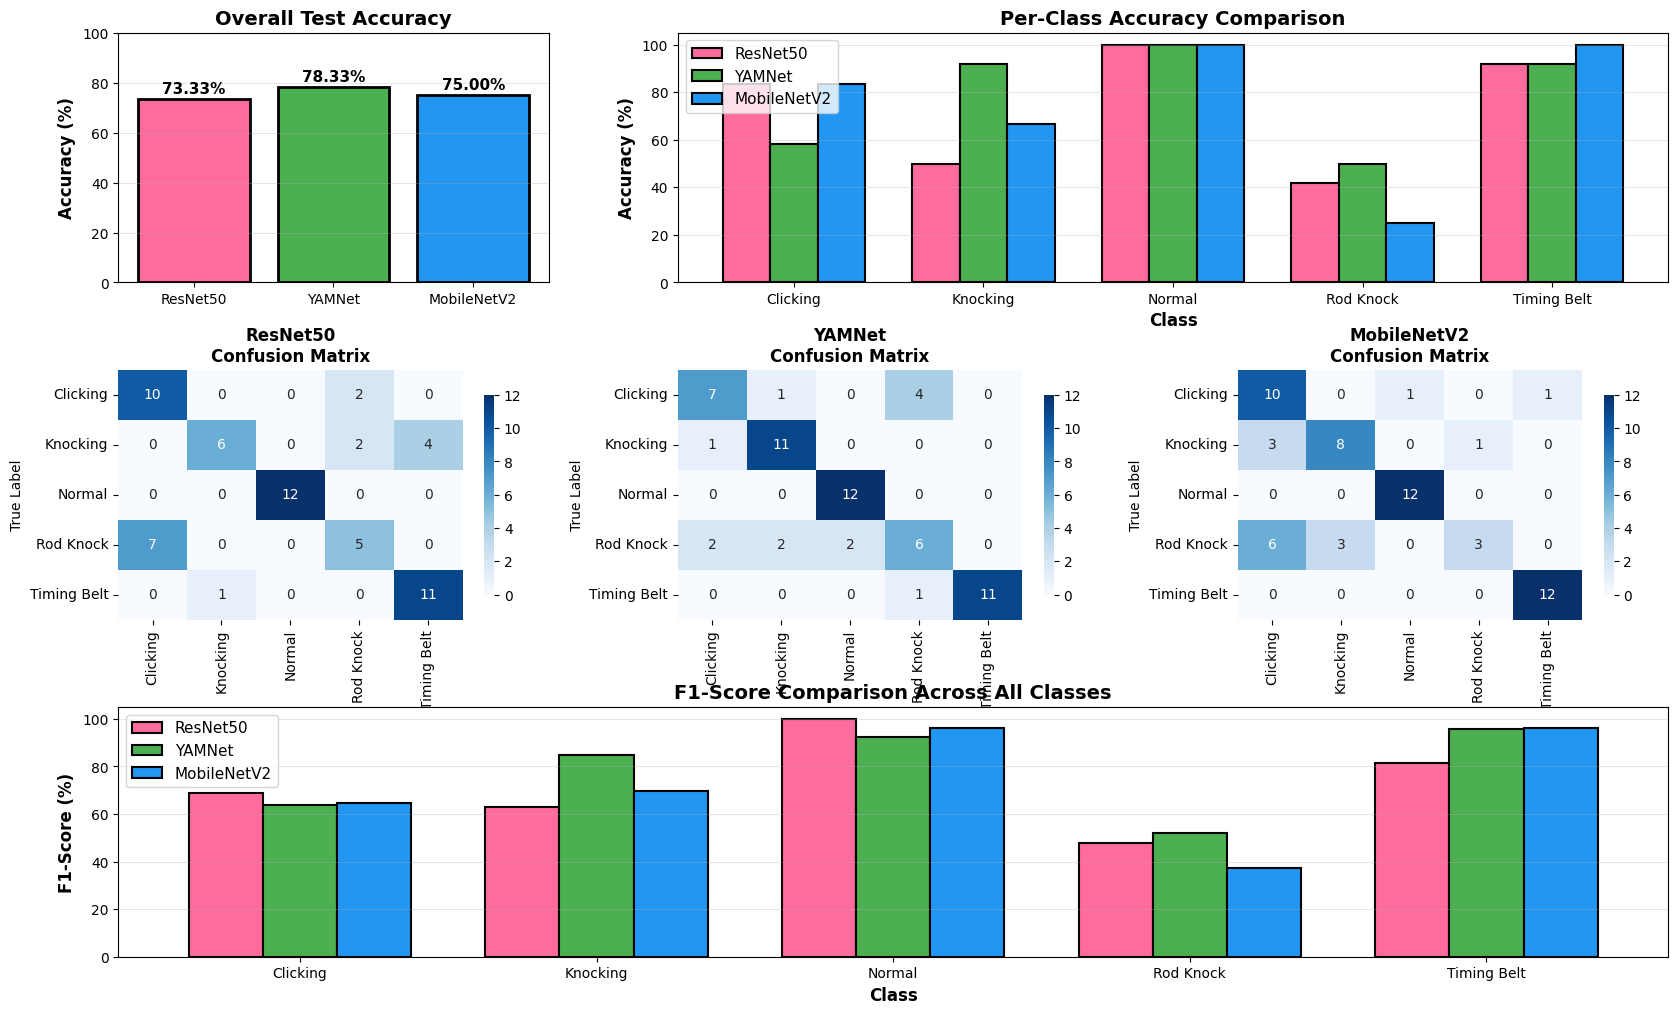

✅ Visualizations saved!

📋 DETAILED CLASSIFICATION REPORTS

ResNet50:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    Clicking       0.59      0.83      0.69        12
    Knocking       0.86      0.50      0.63        12
      Normal       1.00      1.00      1.00        12
   Rod Knock       0.56      0.42      0.48        12
 Timing Belt       0.73      0.92      0.81        12

    accuracy                           0.73        60
   macro avg       0.75      0.73      0.72        60
weighted avg       0.75      0.73      0.72        60


YAMNet:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    Clicking       0.70      0.58      0.64        12
    Knocking       0.79      0.92      0.85        12
      Normal       0.86      1.00      0.92        12
   Rod Knock       0.55      0.50      0.52        12

In [ ]:
import numpy as np
import os
import json
import librosa
import tensorflow as tf
from tensorflow.keras.models import load_model
import tensorflow_hub as hub
from google.colab import drive
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import cv2
from skimage.transform import resize
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("🧪 BATCH TESTING - All 3 Models on Test Dataset")
print("="*80)
print("Testing: ResNet50 | YAMNet | MobileNetV2")
print("Dataset: AS-Augmented_Engine_Data_2k")
print("="*80)

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- CONFIG ---
BASE_PATH = "/content/drive/MyDrive"
TEST_FOLDER = "/content/drive/MyDrive/Testing"

# Audio parameters
SAMPLE_RATE_RESNET = 22050
SAMPLE_RATE_YAMNET = 16000
DURATION = 5
IMG_SIZE = (224, 224)

# Check GPU
print("\n🔍 Checking GPU...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Available: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️ No GPU - Running on CPU (slower)")

# --- VERIFY TEST FOLDER ---
print(f"\n📂 Verifying test folder: {TEST_FOLDER}")
if not os.path.exists(TEST_FOLDER):
    raise FileNotFoundError(f"Test folder not found: {TEST_FOLDER}")

# Get classes
classes = sorted([d for d in os.listdir(TEST_FOLDER)
                  if os.path.isdir(os.path.join(TEST_FOLDER, d))])
num_classes = len(classes)

# Load class mapping
try:
    with open(f"{BASE_PATH}/class_indices.json", 'r') as f:
        class_to_idx = json.load(f)
    print(f"✅ Loaded class mapping: {class_to_idx}")
except:
    # Create mapping from test folder
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    print(f"⚠️ Created class mapping from test folder: {class_to_idx}")

print(f"\n✅ Found {num_classes} classes: {classes}")

# --- COLLECT TEST FILES ---
print("\n📂 Collecting test files...")

test_files = []
test_labels = []
test_class_counts = {cls: 0 for cls in classes}

for class_name in classes:
    class_folder = os.path.join(TEST_FOLDER, class_name)

    if not os.path.exists(class_folder):
        print(f"⚠️ Warning: {class_name} folder not found")
        continue

    audio_files = [f for f in os.listdir(class_folder)
                   if f.endswith(('.wav', '.mp3', '.flac', '.ogg', '.m4a'))]

    test_class_counts[class_name] = len(audio_files)

    for audio_file in audio_files:
        test_files.append(os.path.join(class_folder, audio_file))
        test_labels.append(class_to_idx[class_name])

test_files = np.array(test_files)
test_labels = np.array(test_labels)

print(f"\n📊 Test Dataset Summary:")
for cls, count in test_class_counts.items():
    print(f"   {cls}: {count} files")
print(f"\n✅ Total test samples: {len(test_files)}")

# --- PREPROCESSING FUNCTIONS ---

def audio_to_mel_spectrogram_resnet(audio_path, sr=SAMPLE_RATE_RESNET, duration=DURATION):
    """Convert audio to RGB mel-spectrogram for ResNet50"""
    try:
        y, sr = librosa.load(audio_path, sr=sr, duration=duration)

        target_length = sr * duration
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        else:
            y = y[:target_length]

        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        mel_spec_norm = ((mel_spec_db - mel_spec_db.min()) /
                         (mel_spec_db.max() - mel_spec_db.min()) * 255).astype(np.uint8)

        mel_spec_rgb = np.stack([mel_spec_norm] * 3, axis=-1)
        mel_spec_resized = cv2.resize(mel_spec_rgb, IMG_SIZE, interpolation=cv2.INTER_LINEAR)

        return mel_spec_resized.astype(np.float32)

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.float32)

def audio_to_multichannel_mobilenet(audio_path, sr=SAMPLE_RATE_RESNET, duration=DURATION):
    """Convert audio to multi-channel spectrogram for MobileNetV2"""
    try:
        y, sr = librosa.load(audio_path, sr=sr, duration=duration)

        target_len = sr * duration
        if len(y) < target_len:
            y = np.tile(y, int(np.ceil(target_len/len(y))))[:target_len]
        else:
            y = y[:target_len]

        # Mel spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)

        # Channel 1: Log-Mel
        S_db = librosa.power_to_db(S, ref=np.max)
        S_db_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-6)

        # Channel 2: PCEN
        S_pcen = librosa.pcen(S * (2**31), sr=sr, gain=0.8, bias=10,
                             power=0.25, time_constant=0.400, eps=1e-6)
        S_pcen_norm = (S_pcen - S_pcen.min()) / (S_pcen.max() - S_pcen.min() + 1e-6)

        # Channel 3: Delta
        S_delta = librosa.feature.delta(S_db)
        S_delta_norm = (S_delta - S_delta.min()) / (S_delta.max() - S_delta.min() + 1e-6)

        # Resize
        ch1 = resize(S_db_norm, IMG_SIZE, anti_aliasing=True)
        ch2 = resize(S_pcen_norm, IMG_SIZE, anti_aliasing=True)
        ch3 = resize(S_delta_norm, IMG_SIZE, anti_aliasing=True)

        img_rgb = np.dstack((ch1, ch2, ch3)).astype(np.float32)

        return img_rgb

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.float32)

def load_audio_for_yamnet(audio_path, sr=SAMPLE_RATE_YAMNET, duration=DURATION):
    """Load audio for YAMNet"""
    try:
        y, _ = librosa.load(audio_path, sr=sr, duration=duration, mono=True)

        target_length = sr * duration
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        else:
            y = y[:target_length]

        return y.astype(np.float32)

    except Exception as e:
        print(f"Error loading {audio_path}: {e}")
        return np.zeros(sr * duration, dtype=np.float32)

# --- LOAD MODELS ---
print("\n🤖 Loading models...")

# Load ResNet50
try:
    resnet_model = load_model(f"{BASE_PATH}/resnet50_audio_best.keras")
    print("✅ ResNet50 loaded")
    resnet_available = True
except Exception as e:
    print(f"❌ ResNet50 loading failed: {e}")
    resnet_available = False

# Load YAMNet base + classifier
try:
    yamnet_base = hub.load('https://tfhub.dev/google/yamnet/1')
    yamnet_classifier = load_model(f"{BASE_PATH}/yamnet_audio_best.keras")
    print("✅ YAMNet loaded")
    yamnet_available = True
except Exception as e:
    print(f"❌ YAMNet loading failed: {e}")
    yamnet_available = False

# Load MobileNetV2
try:
    mobilenet_model = load_model(f"{BASE_PATH}/mobilenetv2_fixed_best.keras")
    print("✅ MobileNetV2 loaded")
    mobilenet_available = True
except Exception as e:
    print(f"❌ MobileNetV2 loading failed: {e}")
    mobilenet_available = False

if not any([resnet_available, yamnet_available, mobilenet_available]):
    raise RuntimeError("No models could be loaded!")

# --- BATCH TESTING FUNCTION ---

def batch_test_model(model, preprocess_func, model_name, test_files, test_labels,
                     batch_size=16, is_yamnet=False):
    """Test a model on the entire test dataset"""

    print(f"\n{'='*80}")
    print(f"🧪 Testing {model_name}")
    print(f"{'='*80}")

    predictions = []
    prediction_probs = []

    num_batches = int(np.ceil(len(test_files) / batch_size))

    for i in tqdm(range(num_batches), desc=f"{model_name} Testing"):
        batch_start = i * batch_size
        batch_end = min((i + 1) * batch_size, len(test_files))
        batch_files = test_files[batch_start:batch_end]

        batch_data = []

        for file_path in batch_files:
            if is_yamnet:
                # YAMNet: audio → embedding → classifier
                waveform = load_audio_for_yamnet(file_path)
                scores, embeddings, spectrogram = yamnet_base(waveform)
                embedding = tf.reduce_mean(embeddings, axis=0)
                batch_data.append(embedding.numpy())
            else:
                # ResNet50 / MobileNetV2: audio → spectrogram
                spec = preprocess_func(file_path)
                batch_data.append(spec)

        batch_data = np.array(batch_data)

        # Preprocess for ResNet50 if needed
        if model_name == "ResNet50":
            from tensorflow.keras.applications.resnet50 import preprocess_input
            batch_data = preprocess_input(batch_data)

        # Predict
        batch_preds = model.predict(batch_data, verbose=0)
        prediction_probs.extend(batch_preds)
        predictions.extend(np.argmax(batch_preds, axis=1))

    predictions = np.array(predictions)
    prediction_probs = np.array(prediction_probs)

    # Calculate metrics
    accuracy = accuracy_score(test_labels, predictions)
    cm = confusion_matrix(test_labels, predictions)

    # Per-class accuracy
    per_class_acc = []
    for i in range(num_classes):
        mask = test_labels == i
        if mask.sum() > 0:
            class_acc = (predictions[mask] == i).sum() / mask.sum()
            per_class_acc.append(class_acc * 100)
        else:
            per_class_acc.append(0)

    # Classification report
    report = classification_report(test_labels, predictions, target_names=classes,
                                   output_dict=True)

    print(f"\n📊 {model_name} Results:")
    print(f"   Overall Accuracy: {accuracy*100:.2f}%")
    print(f"\n   Per-Class Accuracy:")
    for i, cls in enumerate(classes):
        print(f"      {cls}: {per_class_acc[i]:.2f}%")

    return {
        'model_name': model_name,
        'predictions': predictions,
        'prediction_probs': prediction_probs,
        'accuracy': accuracy * 100,
        'per_class_accuracy': per_class_acc,
        'confusion_matrix': cm,
        'classification_report': report
    }

# --- RUN TESTS ---
results = {}

if resnet_available:
    results['ResNet50'] = batch_test_model(
        resnet_model,
        audio_to_mel_spectrogram_resnet,
        "ResNet50",
        test_files,
        test_labels,
        batch_size=16
    )

if yamnet_available:
    results['YAMNet'] = batch_test_model(
        yamnet_classifier,
        None,  # Preprocessing handled inside
        "YAMNet",
        test_files,
        test_labels,
        batch_size=32,
        is_yamnet=True
    )

if mobilenet_available:
    results['MobileNetV2'] = batch_test_model(
        mobilenet_model,
        audio_to_multichannel_mobilenet,
        "MobileNetV2",
        test_files,
        test_labels,
        batch_size=16
    )

# --- SAVE RESULTS ---
print("\n💾 Saving test results...")

# Save predictions for each model
for model_name, result in results.items():
    np.save(f"{BASE_PATH}/test_predictions_{model_name.lower()}.npy", result['predictions'])
    np.save(f"{BASE_PATH}/test_probs_{model_name.lower()}.npy", result['prediction_probs'])
    np.save(f"{BASE_PATH}/test_confusion_matrix_{model_name.lower()}.npy", result['confusion_matrix'])

# Save test labels
np.save(f"{BASE_PATH}/test_labels.npy", test_labels)
np.save(f"{BASE_PATH}/test_files.npy", test_files)

print("✅ Results saved!")

# --- COMPARISON TABLE ---
print("\n" + "="*80)
print("📊 TEST RESULTS COMPARISON")
print("="*80)

comparison_data = {
    'Model': [],
    'Overall Accuracy (%)': []
}

# Add per-class columns
for cls in classes:
    comparison_data[f'{cls} (%)'] = []

# Fill data
for model_name in ['ResNet50', 'YAMNet', 'MobileNetV2']:
    if model_name in results:
        comparison_data['Model'].append(model_name)
        comparison_data['Overall Accuracy (%)'].append(f"{results[model_name]['accuracy']:.2f}")

        for i, cls in enumerate(classes):
            comparison_data[f'{cls} (%)'].append(f"{results[model_name]['per_class_accuracy'][i]:.2f}")

df_comparison = pd.DataFrame(comparison_data)
print("\n" + df_comparison.to_string(index=False))
print("="*80)

# Save comparison table
df_comparison.to_csv(f"{BASE_PATH}/test_results_comparison.csv", index=False)

# --- VISUALIZATIONS ---
print("\n📊 Generating comparison visualizations...")

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Plot 1: Overall Accuracy Comparison
ax1 = fig.add_subplot(gs[0, 0])

model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
colors = ['#FF6B9D', '#4CAF50', '#2196F3']

bars = ax1.bar(model_names, accuracies, color=colors[:len(model_names)],
               edgecolor='black', linewidth=2)
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Overall Test Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 100])
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: Per-Class Accuracy Comparison
ax2 = fig.add_subplot(gs[0, 1:])

x = np.arange(num_classes)
width = 0.25

for i, model_name in enumerate(model_names):
    offset = (i - 1) * width
    accs = results[model_name]['per_class_accuracy']
    ax2.bar(x + offset, accs, width, label=model_name,
            color=colors[i], edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Class', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(classes, rotation=0)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 105])

# Plot 3-5: Confusion Matrices
for idx, model_name in enumerate(model_names):
    ax = fig.add_subplot(gs[1, idx])

    cm = results[model_name]['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax,
                cbar_kws={'shrink': 0.8})

    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

# Plot 6: F1-Score Comparison
ax6 = fig.add_subplot(gs[2, :])

f1_scores = {model: [] for model in model_names}
for model_name in model_names:
    report = results[model_name]['classification_report']
    for cls in classes:
        f1_scores[model_name].append(report[cls]['f1-score'] * 100)

x = np.arange(num_classes)
width = 0.25

for i, model_name in enumerate(model_names):
    offset = (i - 1) * width
    ax6.bar(x + offset, f1_scores[model_name], width, label=model_name,
            color=colors[i], edgecolor='black', linewidth=1.5)

ax6.set_xlabel('Class', fontsize=12, fontweight='bold')
ax6.set_ylabel('F1-Score (%)', fontsize=12, fontweight='bold')
ax6.set_title('F1-Score Comparison Across All Classes', fontsize=14, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(classes, rotation=0)
ax6.legend(fontsize=11)
ax6.grid(axis='y', alpha=0.3)
ax6.set_ylim([0, 105])

plt.savefig(f"{BASE_PATH}/test_results_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualizations saved!")

# --- DETAILED CLASSIFICATION REPORTS ---
print("\n" + "="*80)
print("📋 DETAILED CLASSIFICATION REPORTS")
print("="*80)

for model_name in model_names:
    print(f"\n{model_name}:")
    print("-" * 80)
    print(classification_report(test_labels, results[model_name]['predictions'],
                                target_names=classes))

# --- RANKING ---
print("\n" + "="*80)
print("🏆 FINAL TEST RANKING")
print("="*80)

ranked = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)

for rank, (model_name, result) in enumerate(ranked, 1):
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉"
    print(f"\n{medal} {rank}. {model_name}: {result['accuracy']:.2f}%")
    print(f"   Best class: {classes[np.argmax(result['per_class_accuracy'])]} "
          f"({np.max(result['per_class_accuracy']):.2f}%)")
    print(f"   Worst class: {classes[np.argmin(result['per_class_accuracy'])]} "
          f"({np.min(result['per_class_accuracy']):.2f}%)")

# --- SUMMARY ---
print("\n" + "="*80)
print("✅ BATCH TESTING COMPLETE!")
print("="*80)
print(f"\n📁 FILES SAVED:")
print(f"  • test_results_comparison.csv - Summary table")
print(f"  • test_results_comparison.png - Visualizations")
print(f"  • test_predictions_*.npy - Predictions for each model")
print(f"  • test_probs_*.npy - Prediction probabilities")
print(f"  • test_confusion_matrix_*.npy - Confusion matrices")
print(f"  • test_labels.npy - True labels")
print(f"  • test_files.npy - Test file paths")
print(f"\n📊 Dataset Statistics:")
print(f"  • Total test samples: {len(test_files)}")
print(f"  • Classes: {num_classes}")
print(f"  • Samples per class: {dict(test_class_counts)}")
print(f"\n🏆 Winner: {ranked[0][0]} with {ranked[0][1]['accuracy']:.2f}% accuracy")
print("="*80)